In [1]:
import pandas as pd
from utils.ml_utils_v2 import EnsembleProjections
import os
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
ep = EnsembleProjections()

In [4]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [5]:
# Ensemble params
n_scenarios = 1000

# Load data
training_df_log_transformed = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_log_transformed.csv"))
training_df_lags = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_lags.csv"))
ensemble_arima_df = pd.read_parquet(os.path.join(ENSEMBLE_DIR_PATH, f"ensemble_arima_{n_scenarios}.parquet"))

In [6]:
# Print shapes
print(f"Training df log transformed shape: {training_df_log_transformed.shape}")
print(f"Training df lags shape: {training_df_lags.shape}")
print(f"Ensemble ARIMA df shape: {ensemble_arima_df.shape}") 

Training df log transformed shape: (3652, 19)
Training df lags shape: (3652, 19)
Ensemble ARIMA df shape: (1494000, 17)


In [7]:
# Get the models from the models directory with keys without .pkl extension
models = {}
for model_name in os.listdir(MODELS_DIR_PATH):
    if model_name.endswith(".pkl"):
        model_path = os.path.join(MODELS_DIR_PATH, model_name)
        key_name = model_name[:-4]  # remove .pkl extension
        models[key_name] = joblib.load(model_path)

models.keys()

/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.0 when 

dict_keys(['reg_no_isos_xgb_pipeline', 'reg_no_isos_enet_pipeline', 'reg_with_isos_enet_pipeline', 'reg_with_isos_xgb_pipeline'])

In [8]:
# Get a df with only iso_alpha_3, income_group and region cols
iso_alpha_3_cols = ["iso_alpha_3", "income_group", "region"]
income_group_region_mapping_df = training_df_log_transformed[iso_alpha_3_cols].drop_duplicates().reset_index(drop=True)
income_group_region_mapping_df.head()

,iso_alpha_3,income_group,region
0,ABW,High income,Latin America & Caribbean
1,AFG,Low income,South Asia
2,AGO,Lower middle income,Africa Eastern and Southern
3,ALB,Upper middle income,Europe & Central Asia
4,ARE,High income,Middle East & North Africa


In [9]:
emission_init_cond_df = training_df_lags[training_df_lags["year"] == 2022].copy()
emission_init_cond_df = emission_init_cond_df.reset_index(drop=True)
emission_init_cond_df = emission_init_cond_df[["iso_alpha_3", "year", "total_emissions"]]
emission_init_cond_df

,iso_alpha_3,year,total_emissions
0,ABW,2022,0.496683
1,AFG,2022,38.457458
2,AGO,2022,136.889648
3,ALB,2022,9.252882
4,ARE,2022,286.675891
...,...,...,...
161,VNM,2022,449.692567
162,YEM,2022,36.119043
163,ZAF,2022,503.193706
164,ZMB,2022,77.421588


In [10]:
training_df_log_transformed.columns

Index(['iso_alpha_3', 'income_group', 'region', 'year', 'pop_growth',
       'renewable_energy_consumption_pct', 'forest_area_pct', 'gdp_growth_pct',
       'gdp_per_capita_growth_pct', 'manufacturing_pct_of_gdp',
       'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd', 'log_imports_pct_of_gdp',
       'log_industry_pct_of_gdp', 'log_exports_pct_of_gdp',
       'log_total_emissions', 'log_gdp_2021_ppp_intl_usd_lag1',
       'log_pop_total_lag1'],
      dtype='object')

In [12]:
features_init_cond_df = training_df_log_transformed[training_df_log_transformed["year"] == 2022].copy()
features_init_cond_df = features_init_cond_df.reset_index(drop=True)
features_init_cond_df = features_init_cond_df.drop(columns=["income_group", "region"])
features_init_cond_df

,iso_alpha_3,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,log_gdp_2021_ppp_intl_usd,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_total_emissions,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1
0,ABW,2022,-0.362774,8.8,2.333333,8.517918,8.912308,4.100964,11.583486,22.151653,10.568201,4.457991,2.651547,4.483796,0.403251,22.069907,11.587114
1,AFG,2022,1.435704,20.0,1.852782,-6.240172,-7.576669,10.190262,17.518757,25.110473,7.592220,4.016481,2.836172,2.964244,3.675223,25.174907,17.504400
2,AGO,2022,3.143026,49.0,52.536497,3.044727,-0.143628,7.449769,17.388840,26.297735,8.909031,3.269547,3.832548,3.815328,4.926454,26.267742,17.357409
3,ALB,2022,-1.215790,41.9,28.791971,4.826696,6.108948,7.504617,14.837130,24.584662,9.747591,3.881584,3.179097,3.642759,2.327559,24.537524,14.849288
4,ARE,2022,5.088342,0.1,4.467756,7.509697,2.176083,9.820748,16.125565,27.265510,11.139959,4.455895,3.952845,4.652171,5.661834,27.193099,16.074682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,VNM,2022,0.750757,24.2,47.203322,8.537500,7.725699,24.777229,18.417482,27.888629,9.471224,4.507927,3.675854,4.547754,6.110785,27.806703,18.409975
162,YEM,2022,2.873344,3.7,1.039832,0.752448,-2.186490,12.366776,17.458945,27.412526,9.595607,3.877881,3.274991,2.277893,3.614130,27.412526,17.430211
163,ZAF,2022,1.413972,7.8,13.995079,1.911480,0.480620,12.428101,17.948730,27.479500,9.530842,3.478515,3.255588,3.537226,6.222961,27.460565,17.934590
164,ZMB,2022,2.763650,83.5,59.776969,5.211224,2.343365,7.996353,16.818861,25.003409,8.184827,3.404635,3.591372,3.718293,4.362099,24.952609,16.791224


In [13]:
ensemble_arima_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,log_gdp_2021_ppp_intl_usd,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1
0,ABW,id_ABW_1,2022,0.117545,6.886715,-0.856085,-14.454422,-13.140864,5.003948,11.578722,0.697800,10.543822,4.556864,2.617507,5.134121,-13.632678,11.587034
1,ABW,id_ABW_1,2023,-0.228003,6.556347,0.875420,-0.755354,7.499505,3.856354,11.575512,29.804776,10.462886,4.600133,2.601874,4.433165,6.281286,11.590305
2,ABW,id_ABW_1,2024,-0.161398,6.566251,2.485552,16.332003,-15.315406,3.305136,11.583369,-21.312532,10.572772,4.648658,2.661402,3.647679,24.189466,11.591779
3,ABW,id_ABW_1,2025,-0.559556,7.432006,-0.226877,4.530573,5.148173,4.585939,11.595238,-25.233150,10.679861,4.698198,2.719551,1.962396,37.400970,11.588246
4,ABW,id_ABW_1,2026,-0.945273,5.372673,-0.107360,-25.174864,0.626307,4.715190,11.604039,15.142736,10.583912,4.691172,2.608958,-2.871147,-46.721073,11.584534


In [14]:
# Merge the income group and region mapping df with the ensemble df
ensemble_arima_df = pd.merge(ensemble_arima_df, income_group_region_mapping_df,
                             on="iso_alpha_3", how="left")

ensemble_arima_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,log_gdp_2021_ppp_intl_usd,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,income_group,region
0,ABW,id_ABW_1,2022,0.117545,6.886715,-0.856085,-14.454422,-13.140864,5.003948,11.578722,0.697800,10.543822,4.556864,2.617507,5.134121,-13.632678,11.587034,High income,Latin America & Caribbean
1,ABW,id_ABW_1,2023,-0.228003,6.556347,0.875420,-0.755354,7.499505,3.856354,11.575512,29.804776,10.462886,4.600133,2.601874,4.433165,6.281286,11.590305,High income,Latin America & Caribbean
2,ABW,id_ABW_1,2024,-0.161398,6.566251,2.485552,16.332003,-15.315406,3.305136,11.583369,-21.312532,10.572772,4.648658,2.661402,3.647679,24.189466,11.591779,High income,Latin America & Caribbean
3,ABW,id_ABW_1,2025,-0.559556,7.432006,-0.226877,4.530573,5.148173,4.585939,11.595238,-25.233150,10.679861,4.698198,2.719551,1.962396,37.400970,11.588246,High income,Latin America & Caribbean
4,ABW,id_ABW_1,2026,-0.945273,5.372673,-0.107360,-25.174864,0.626307,4.715190,11.604039,15.142736,10.583912,4.691172,2.608958,-2.871147,-46.721073,11.584534,High income,Latin America & Caribbean


## Let's check the feature variables projections

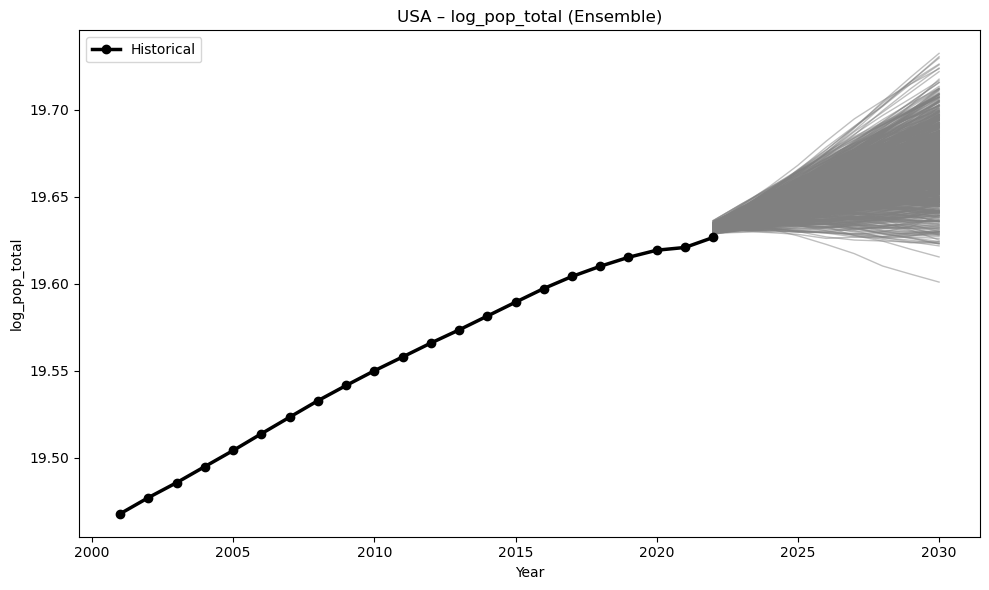

In [15]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_pop_total",
    hist_df=training_df_log_transformed)

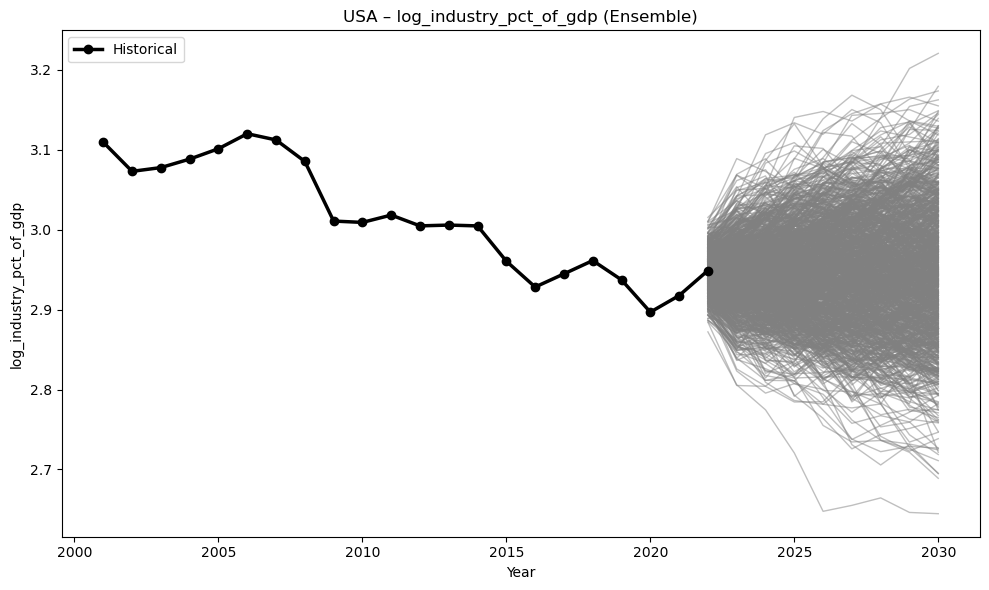

In [16]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_industry_pct_of_gdp",
    hist_df=training_df_log_transformed)

### We need to rescale the features so they match with the intial year (2022)

In [ ]:
ensemble_arima_df.head()

In [17]:
calibrated_ensemble_arima_df = ep.calibrate_to_initial_conditions(
    simulated_df=ensemble_arima_df,
    initial_conditions_df=features_init_cond_df,  # your 2022 table
    base_year=2022,
    # columns=None -> auto-intersection
    update_logs=True,                 # keeps log_* in sync if present
    log_prefix="log_"
)


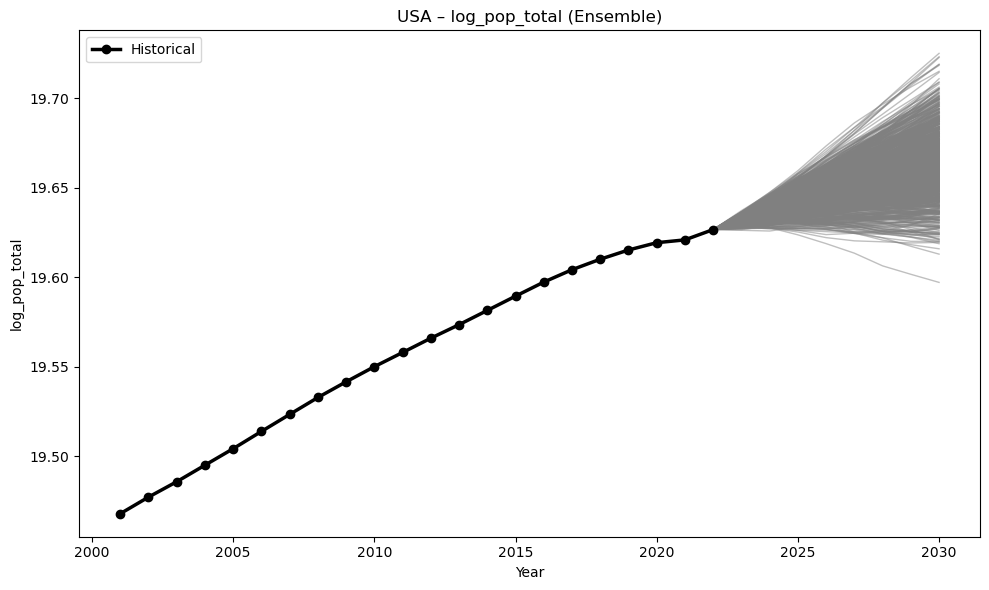

In [18]:
ep.plot_ensemble_time_series(
    df=calibrated_ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_pop_total",
    hist_df=training_df_log_transformed)

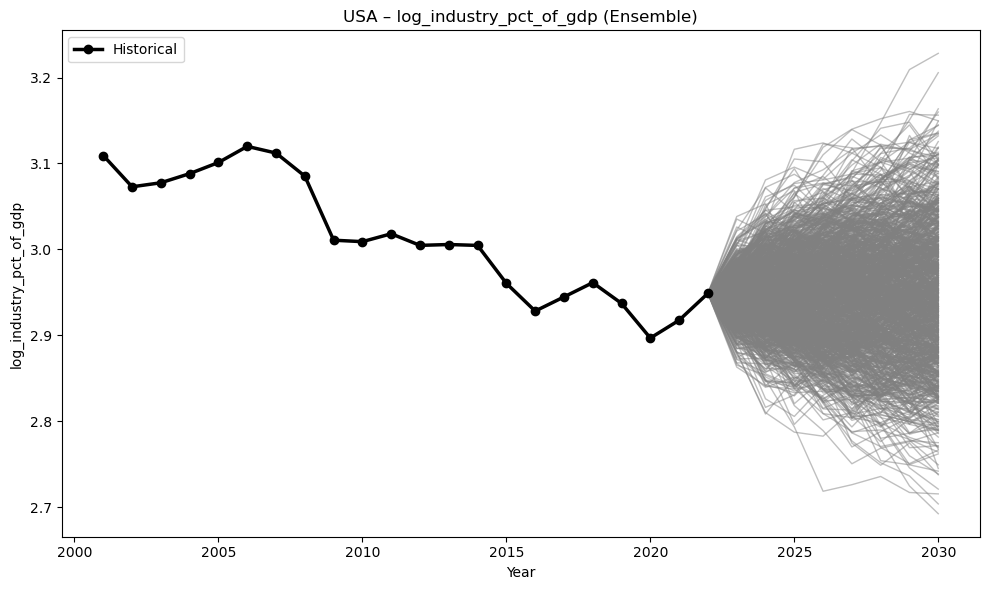

In [19]:
ep.plot_ensemble_time_series(
    df=calibrated_ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_industry_pct_of_gdp",
    hist_df=training_df_log_transformed)

## Let's do a prediction and see how it looks without rescaling

In [20]:
# Get feature cols
feature_cols_no_isos = [c for c in  training_df_log_transformed.columns if c not in ["iso_alpha_3", "log_total_emissions"]]
feature_cols_no_isos

['income_group',
 'region',
 'year',
 'pop_growth',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_growth_pct',
 'gdp_per_capita_growth_pct',
 'manufacturing_pct_of_gdp',
 'log_pop_total',
 'log_gdp_2021_ppp_intl_usd',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_imports_pct_of_gdp',
 'log_industry_pct_of_gdp',
 'log_exports_pct_of_gdp',
 'log_gdp_2021_ppp_intl_usd_lag1',
 'log_pop_total_lag1']

In [21]:
feature_cols_with_isos = [c for c in training_df_log_transformed.columns if c not in ["log_total_emissions"]]
feature_cols_with_isos

['iso_alpha_3',
 'income_group',
 'region',
 'year',
 'pop_growth',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_growth_pct',
 'gdp_per_capita_growth_pct',
 'manufacturing_pct_of_gdp',
 'log_pop_total',
 'log_gdp_2021_ppp_intl_usd',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_imports_pct_of_gdp',
 'log_industry_pct_of_gdp',
 'log_exports_pct_of_gdp',
 'log_gdp_2021_ppp_intl_usd_lag1',
 'log_pop_total_lag1']

In [22]:
xgb_no_isos_df = ep.predict_ensemble_emissions(calibrated_ensemble_arima_df, models["reg_no_isos_xgb_pipeline"], feature_cols=feature_cols_no_isos)
xgb_no_isos_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,...,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,income_group,region,log_total_emissions,total_emissions
0,ABW,id_ABW_1,2022,-0.362774,8.800000,2.333333,8.517918,8.912308,4.100964,11.583486,...,10.568201,4.457991,2.651547,4.483796,22.069907,11.587114,High income,Latin America & Caribbean,0.277804,1.320228
1,ABW,id_ABW_1,2023,0.703678,8.377848,-2.386031,0.445126,-5.086264,3.160458,11.580275,...,10.487078,4.500321,2.635710,3.871628,-10.168758,11.590386,High income,Latin America & Caribbean,0.582448,1.790417
2,ABW,id_ABW_1,2024,0.498116,8.390504,-6.774582,-9.624367,10.387111,2.708710,11.588136,...,10.597218,4.547793,2.696012,3.185638,-39.160264,11.591860,High income,Latin America & Caribbean,0.316683,1.372567
3,ABW,id_ABW_1,2025,1.726935,9.496785,0.618372,-2.669844,-3.491559,3.758386,11.600010,...,10.704555,4.596258,2.754918,1.713825,-60.548334,11.588326,High income,Latin America & Caribbean,0.188423,1.207345
4,ABW,id_ABW_1,2026,2.917357,6.865323,0.292618,14.835420,-0.424769,3.864313,11.608814,...,10.608384,4.589385,2.642886,-2.507467,75.636625,11.584614,High income,Latin America & Caribbean,0.519823,1.681730


In [23]:
enet_no_isos_df = ep.predict_ensemble_emissions(calibrated_ensemble_arima_df, models["reg_no_isos_enet_pipeline"], feature_cols=feature_cols_no_isos)
xgb_with_isos_df = ep.predict_ensemble_emissions(calibrated_ensemble_arima_df, models["reg_with_isos_xgb_pipeline"], feature_cols=feature_cols_with_isos)
enet_with_isos_df = ep.predict_ensemble_emissions(calibrated_ensemble_arima_df, models["reg_with_isos_enet_pipeline"], feature_cols=feature_cols_with_isos)

/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


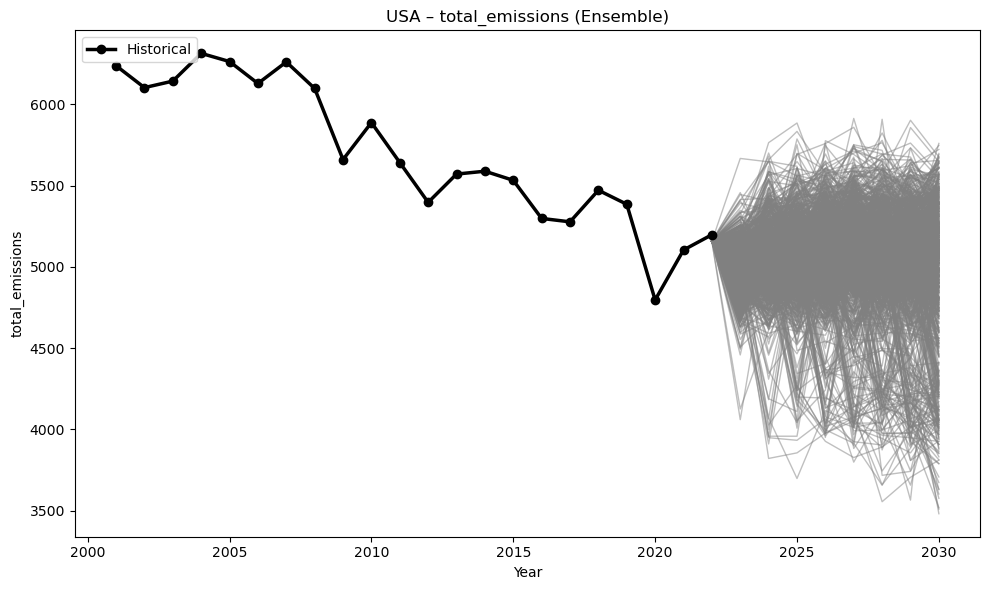

In [24]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

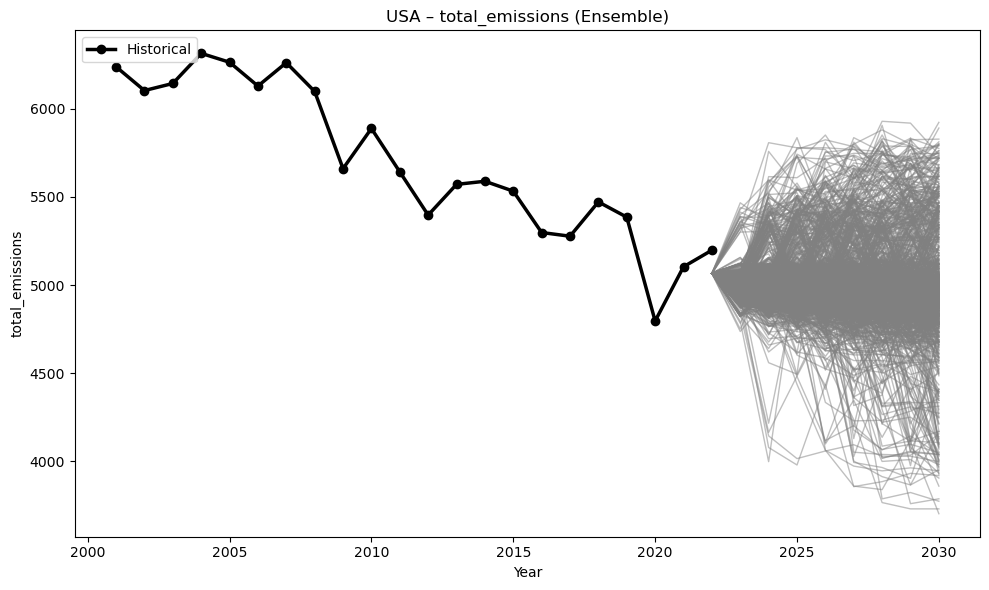

In [25]:
ep.plot_ensemble_time_series(
    df=xgb_with_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

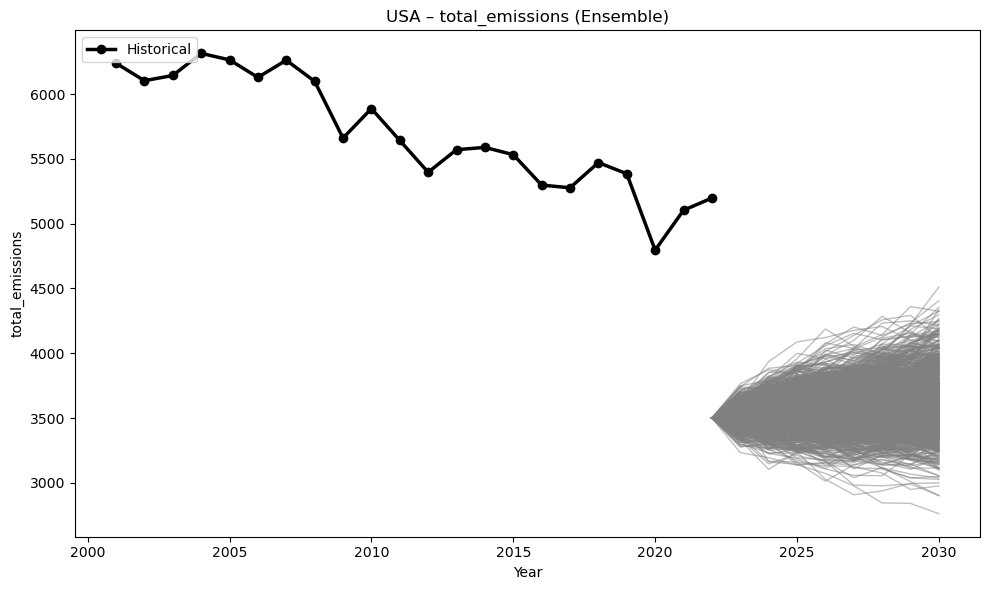

In [26]:
ep.plot_ensemble_time_series(
    df=enet_no_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

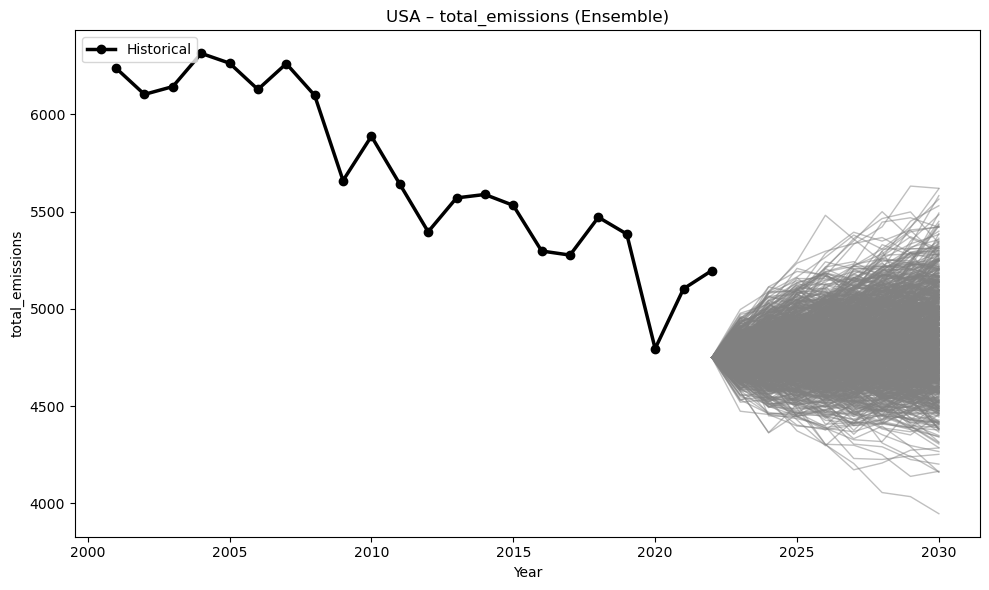

In [27]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

## Let's calibrate emissions and plot again

In [ ]:
# xgb_no_isos_df_calibrated = ep.calibrate_total_emissions(
#     simulated_df=xgb_no_isos_df,
#     initial_emissions_df=emission_init_cond_df,
#     adjustment_method="multiplicative"
# )

# enet_with_isos_df_calibrated = ep.calibrate_total_emissions(
#     simulated_df=enet_with_isos_df,
#     initial_emissions_df=emission_init_cond_df,
#     adjustment_method="multiplicative"
# )

In [ ]:
xgb_no_isos_df_calibrated = ep.calibrate_to_initial_conditions(
    simulated_df=xgb_no_isos_df,
    initial_conditions_df=emission_init_cond_df,
    base_year=2022,
    adjustment_method="multiplicative"
)

enet_with_isos_df_calibrated = ep.calibrate_to_initial_conditions(
    simulated_df=enet_with_isos_df,
    initial_conditions_df=emission_init_cond_df,
    base_year=2022,
    adjustment_method="multiplicative"
)

In [39]:
xgb_no_isos_df_calibrated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494000 entries, 0 to 1493999
Data columns (total 21 columns):
 #   Column                                Non-Null Count    Dtype  
---  ------                                --------------    -----  
 0   iso_alpha_3                           1494000 non-null  object 
 1   future_id                             1494000 non-null  object 
 2   year                                  1494000 non-null  int64  
 3   pop_growth                            1494000 non-null  float64
 4   renewable_energy_consumption_pct      1494000 non-null  float64
 5   forest_area_pct                       1494000 non-null  float64
 6   gdp_growth_pct                        1494000 non-null  float64
 7   gdp_per_capita_growth_pct             1494000 non-null  float64
 8   manufacturing_pct_of_gdp              1494000 non-null  float64
 9   log_pop_total                         1494000 non-null  float64
 10  log_gdp_2021_ppp_intl_usd             1494000 non-null

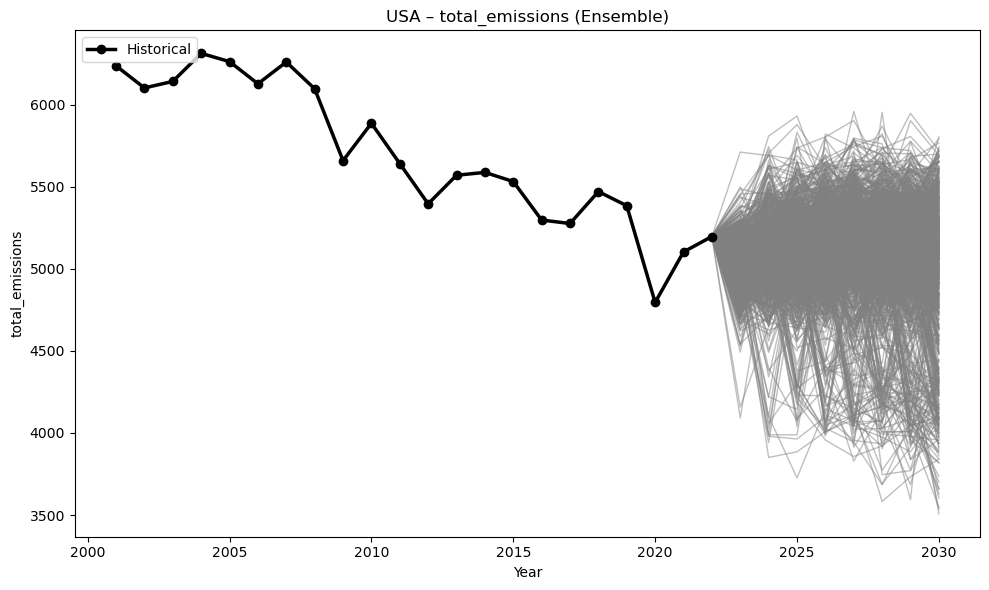

In [36]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df_calibrated, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

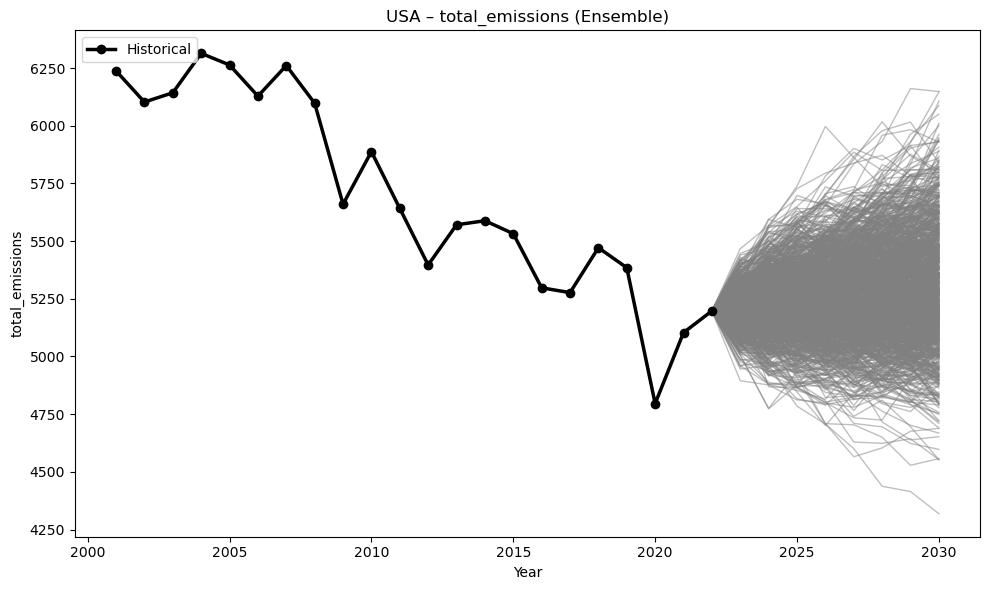

In [37]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df_calibrated, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)